# Catalog-driven California continuation: ETAS vs Ogata thinning

Same comparison workflow as `multi_event_history_california_catalog_continuation.ipynb`, but the **history comes from a real catalog file** and the **time windows / fitted parameters** follow `grid_continuation_point_process.ipynb`:

- `AUXILIARY_START`, `TIMEWINDOW_START`, `TIMEWINDOW_END`, `TESTWINDOW_END`
- catalog from `CATALOG_PATH`, polygon from inversion `shape_coords`
- ETAS parameters from inversion (`ETASParameterCalculation`), cached under `INVERSION_OUTPUT_DIR`

Forecast window: **`TIMEWINDOW_END` → `TESTWINDOW_END`**. One stochastic catalog continuation each for classic ETAS and branching Ogata thinning.

In [1]:
from typing import TypedDict
import datetime as dt

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import pyproj
import scipy
import shapely
import etas.mc_b_est as mc_b_est
import etas.utility_functions as utility_functions
import etas.simulation as simulation
from etas.inversion import polygon_surface, haversine
from etas.inversion import ETASParameterCalculation
from matplotlib import colors
from matplotlib.path import Path as MplPath
from scipy.optimize import root_scalar
from shapely.geometry import MultiPoint, MultiPolygon, Point, Polygon
from shapely.ops import voronoi_diagram
from shapely.prepared import prep
from tqdm.auto import tqdm



%matplotlib inline


2026-06-26 10:19:30.890746: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-26 10:19:30.929029: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-26 10:19:30.929072: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-26 10:19:30.930708: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-26 10:19:30.938243: I tensorflow/core/platform/cpu_feature_guar

2026-06-26 10:19:32,993 - DEBUG - Loaded backend inline version unknown.


In [2]:
EARTH_RADIUS_KM = utility_functions.EARTH_RADIUS_KM


In [3]:
# Nodes per axis for A_h's parent-centered refined quadrature (log_rhs, thinning, saved CSV tag).
A_H_RESOLUTION = 500


class History(TypedDict):
    """Parent event in ETAS catalog convention: x=longitude, y=latitude."""

    m: float
    x: float  # longitude (degrees)
    y: float  # latitude (degrees)
    t: float


class EtasParams(TypedDict):
    mu: float
    k0: float
    a: float
    m_c: float
    d: float
    gamma: float
    rho: float
    c: float
    tau: float
    omega: float


def polygon_lat_lon_arrays(poly: Polygon) -> tuple[np.ndarray, np.ndarray]:
    """Return (lat, lon) arrays from polygon vertices in ETAS order (x=lat, y=lon)."""
    coords = np.asarray(poly.exterior.coords)
    return coords[:, 0], coords[:, 1]


def plot_polygon_map(ax, poly: Polygon, **plot_kwargs):
    """Plot an ETAS polygon on a map axis where matplotlib x=lon, y=lat."""
    lats, lons = polygon_lat_lon_arrays(poly)
    ax.plot(lons, lats, **plot_kwargs)


def a_h(
    lat: float,
    lon: float,
    H: History,
    params: EtasParams,
):
    """Spatial triggering kernel at (lat, lon) from history event H."""
    dist_sq_km2 = utility_functions.spatial_distance_squared_km2(
        lat, lon, H["y"], H["x"]
    )
    K = params["k0"] * np.exp(params["a"] * (H["m"] - params["m_c"]))
    C = params["d"] * np.exp(params["gamma"] * (H["m"] - params["m_c"]))
    return K / (dist_sq_km2 + C) ** (1 + params["rho"])


_A_H_CACHE: dict = {}


def A_h(
    poly: Polygon,
    H: History,
    params: EtasParams,
    resolution: int = 500,
    stretch: float = 3.5,
) -> float:
    """Integrate a_h over poly in km^2 with a grid refined around the parent.

    The spatial kernel is sharply peaked (half-width ~sqrt(C), only a few km), so a
    uniform grid over a large polygon's bounding box badly under-resolves the spike
    and underestimates the integral. Here the quadrature nodes are centered on the
    parent H and concentrated near it (``stretch`` > 1 packs nodes toward r=0), then
    clipped to the polygon. The result does not depend on t and callers (thinning,
    log_rhs) request it repeatedly with identical arguments, so it is cached.

    Polygon vertices follow ETAS inversion convention: Shapely (x, y) = (lat, lon).
    """
    min_lat, min_lon, max_lat, max_lon = poly.bounds
    if min_lat == max_lat or min_lon == max_lon:
        return 0.0

    key = (
        poly.wkt,
        H["m"], H["x"], H["y"],
        params["k0"], params["a"], params["d"],
        params["gamma"], params["rho"], params["m_c"],
        resolution, stretch,
    )
    cached = _A_H_CACHE.get(key)
    if cached is not None:
        return cached

    lat0, lon0 = H["y"], H["x"]
    km_per_lat, km_per_lon = utility_functions.km_per_degree_at_latitude(lat0)

    # Extent (km) from the parent out to the farthest bounding-box edge per axis.
    ext_y = max(abs(max_lat - lat0), abs(lat0 - min_lat)) * km_per_lat
    ext_x = max(abs(max_lon - lon0), abs(lon0 - min_lon)) * km_per_lon

    # Nodes packed near the parent (u**stretch), giving fine spacing where the kernel lives.
    u = np.linspace(-1.0, 1.0, resolution)
    sx = np.sign(u) * np.abs(u) ** stretch * ext_x
    sy = np.sign(u) * np.abs(u) ** stretch * ext_y
    SX, SY = np.meshgrid(sx, sy)
    WX, WY = np.meshgrid(np.gradient(sx), np.gradient(sy))
    dA_km2 = np.abs(WX * WY)

    LAT = lat0 + SY / km_per_lat
    LON = lon0 + SX / km_per_lon

    mask = MplPath(poly.exterior.coords).contains_points(
        np.column_stack((LAT.ravel(), LON.ravel()))
    ).reshape(LAT.shape)

    K = params["k0"] * np.exp(params["a"] * (H["m"] - params["m_c"]))
    C = params["d"] * np.exp(params["gamma"] * (H["m"] - params["m_c"]))
    dist_sq_km2 = utility_functions.spatial_distance_squared_km2(
        LAT.ravel(), LON.ravel(), H["y"], H["x"]
    ).reshape(LAT.shape)
    kernel = K / (dist_sq_km2 + C) ** (1 + params["rho"])

    val = float(np.sum((kernel * dA_km2)[mask]))
    _A_H_CACHE[key] = val
    return val


def polygon_area(polygon: Polygon) -> float:
    geod = pyproj.Geod(ellps="WGS84")
    # ETAS convention stores Shapely (x, y) = (lat, lon); pyproj wants (lon, lat).
    lon_lat = Polygon([(lon, lat) for lat, lon in polygon.exterior.coords])
    area_m2, _ = geod.geometry_area_perimeter(lon_lat)
    return abs(area_m2) / 1e6


def g(
    t: float,
    H : History,
    params: EtasParams,
    ):
    return np.exp(-(t - H['t']) / params['tau']) / (t - H['t'] + params['c'])**(1+params['omega'])


def etas_rate_at_latlon(
    lat: float,
    lon: float,
    t: float,
    H : History,
    params: EtasParams,
    ):
    return params['mu'] + a_h(lat, lon, H, params) * g(t, H, params)


def etas_rate_space_integrated(t, S, polygon, H, params, resolution: int = 50):
    return params['mu']*S +A_h(polygon, H, params, resolution) * g(t, H, params)


def unreg_gamma_old(a, x):
    return scipy.special.gammaincc(a, x) * scipy.special.gamma(a)


def unreg_gamma(a, x):
    """
    Computes the upper incomplete gamma function Gamma(a, x).
    Uses the recurrence relation to handle negative 'a' (e.g., a = -omega).
    """
    if a > 0:
        return scipy.special.gammaincc(a, x) * scipy.special.gamma(a)

    elif -1 < a < 0:
        # Shift the parameter to a+1 > 0
        a_plus_1 = a + 1.0
        gamma_a_plus_1 = scipy.special.gammaincc(a_plus_1, x) * scipy.special.gamma(a_plus_1)
        return (gamma_a_plus_1 - (x**a) * np.exp(-x)) / a
    else:
        raise ValueError("Parameter 'a' is out of bounds for standard ETAS omega values.")


# ----- multi-event helpers: history is a DataFrame; intensity sums over all parents -----

def to_history_dict(row) -> History:
    """One catalog row -> single-event History dict (ETAS coords: x=lon, y=lat)."""
    return {
        "m": float(row["m"]),
        "x": float(row["x"]),
        "y": float(row["y"]),
        "t": float(row["t"]),
    }


def lambda_s_total(t, events, poly, params, resolution: int = A_H_RESOLUTION) -> float:
    """Space-integrated temporal intensity at t: mu*area + sum_i A_h(poly, H_i) * g(t, H_i).

    Sums over every parent event with t_i <= t (history plus already-generated aftershocks),
    so it is the self-exciting (Hawkes/ETAS) intensity used for branching thinning.
    """
    rate = params["mu"] * polygon_area(poly)
    for H in events:
        if H["t"] <= t:
            rate += A_h(poly, H, params, resolution) * g(t, H, params)
    return rate


def parent_weights(t, events, poly, params, resolution: int = A_H_RESOLUTION):
    """Probabilities for the parent of an event at t: one per active event (t_i < t), background last."""
    contribs = [
        (A_h(poly, H, params, resolution) * g(t, H, params)) if H["t"] < t else 0.0
        for H in events
    ]
    contribs.append(params["mu"] * polygon_area(poly))  # background as the final option
    w = np.asarray(contribs, dtype=float)
    return w / w.sum()


def sample_background_location(poly: Polygon):
    """Uniform (lat, lon) inside the polygon via rejection sampling (poly coords are (lat, lon))."""
    min_lat, min_lon, max_lat, max_lon = poly.bounds
    while True:
        lat = np.random.uniform(min_lat, max_lat)
        lon = np.random.uniform(min_lon, max_lon)
        if poly.contains(Point(lat, lon)):
            return lat, lon


def sample_aftershock_location(H: History, params: EtasParams):
    """Isotropic aftershock (lat, lon) around parent H using the ETAS radial kernel."""
    r = simulation.simulate_aftershock_radius(
        params["log10_d"], params["gamma"], params["rho"], [H["m"]], params["m_c"]
    )[0]
    angle = np.random.uniform(0, 2 * np.pi)
    km_per_lat, km_per_lon = utility_functions.km_per_degree_at_latitude(H["y"])
    lat = H["y"] + (r * np.cos(angle)) / km_per_lat
    lon = H["x"] + (r * np.sin(angle)) / km_per_lon
    return float(lat), float(lon)

def expand_theta_log10(theta: dict) -> dict:
    """Copy theta and add linear keys for each finite log10_* entry (skip None, e.g. log10_iota)."""
    out = dict(theta)
    for key, val in list(out.items()):
        if not key.startswith("log10_") or val is None:
            continue
        linear = key.replace("log10_", "", 1)
        if linear not in out or out.get(linear) is None:
            out[linear] = 10.0 ** float(val)
    return out

def filter_catalog_to_polygon(cat: pd.DataFrame, poly: Polygon) -> pd.DataFrame:
    """Keep only rows whose (y=lat, x=lon) intersect poly — same geometry as ETAS filter_polygon."""
    if cat.empty:
        return cat
    gdf = gpd.GeoDataFrame(cat, geometry=gpd.points_from_xy(cat["y"], cat["x"]))
    return gdf[gdf.intersects(poly)].drop(columns="geometry").reset_index(drop=True)



In [4]:
from pathlib import Path
import datetime as dt
import hashlib
import json
import os

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

# --- time windows (UTC strings, same as grid_continuation_point_process.ipynb) ---
AUXILIARY_START = "1971-01-01 00:00:00"
TIMEWINDOW_START = "1981-01-01 00:00:00"
TIMEWINDOW_END = "2007-01-01 00:00:00"   # forecast start
TESTWINDOW_END = "2021-01-01 00:00:00"   # forecast end

# --- catalog & region ---
CATALOG_PATH = REPO_ROOT / "input_data" / "example_catalog.csv"
SHAPE_COORDS_PATH = REPO_ROOT / "input_data" / "california_shape.npy"

# --- inversion metadata (template invert_etas_config.json + forced completeness) ---
MC = 3.6
DELTA_M = 0.1
COPPERSMITH_MULTIPLIER = 100
THETA_0 = {
    "log10_mu": -5.8,
    "log10_k0": -2.6,
    "a": 1.8,
    "log10_c": -2.5,
    "omega": -0.02,
    "log10_tau": 3.5,
    "log10_d": -0.85,
    "gamma": 1.3,
    "rho": 0.66,
}
INVERSION_OUTPUT_DIR = REPO_ROOT / "outputs" / "notebook_catalog_etas_vs_thinning" / "inversions"
FORCE_INVERSION = False
STORE_PIJ = True
STORE_DISTANCES = True
GOF_THRESHOLD = 1.0

# --- single catalog-continuation forecast ---
SEED = 0

print("Configuration loaded:")
print(f"  catalog: {CATALOG_PATH}")
print(f"  shape:   {SHAPE_COORDS_PATH}")
print(f"  forecast window: {TIMEWINDOW_END} -> {TESTWINDOW_END}")


Configuration loaded:
  catalog: /home/neriberman/Repos/etas/input_data/example_catalog.csv
  shape:   /home/neriberman/Repos/etas/input_data/california_shape.npy
  forecast window: 2007-01-01 00:00:00 -> 2021-01-01 00:00:00


## Inversion + fitted parameters

In [5]:
def inversion_id_from_config(cfg, *, store_pij=False, store_distances=False):
    key_params = {
        "fn_catalog": str(cfg.get("fn_catalog", "")),
        "auxiliary_start": str(cfg.get("auxiliary_start", "")),
        "timewindow_start": str(cfg.get("timewindow_start", "")),
        "timewindow_end": str(cfg.get("timewindow_end", "")),
        "testwindow_end": str(cfg.get("testwindow_end", "")),
        "mc": str(cfg.get("mc")),
        "delta_m": str(cfg.get("delta_m")),
        "store_pij": str(store_pij),
        "store_distances": str(store_distances),
        "shape_coords": str(cfg.get("shape_coords")),
    }
    return hashlib.sha1(json.dumps(key_params, sort_keys=True).encode()).hexdigest()[:16]


inversion_config = {
    "fn_catalog": str(CATALOG_PATH),
    "data_path": str(INVERSION_OUTPUT_DIR) + os.sep,
    "auxiliary_start": AUXILIARY_START,
    "timewindow_start": TIMEWINDOW_START,
    "timewindow_end": TIMEWINDOW_END,
    "testwindow_end": TESTWINDOW_END,
    "theta_0": THETA_0,
    "mc": MC,
    "delta_m": DELTA_M,
    "coppersmith_multiplier": COPPERSMITH_MULTIPLIER,
    "shape_coords": str(SHAPE_COORDS_PATH),
}

inv_id = inversion_id_from_config(
    inversion_config, store_pij=STORE_PIJ, store_distances=STORE_DISTANCES
)
inv_run_dir = INVERSION_OUTPUT_DIR / f"inv_{inv_id}"
params_json = inv_run_dir / f"parameters_{inv_id}.json"

print(f"inversion id: {inv_id}")
print(f"expected parameters file: {params_json}")

if params_json.exists() and not FORCE_INVERSION:
    print("Using cached inversion parameters.")
else:
    print("Running ETAS inversion (this may take a while)...")
    inversion_config["id"] = inv_id
    inv_run_dir.mkdir(parents=True, exist_ok=True)
    INVERSION_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    calc = ETASParameterCalculation(inversion_config)
    calc.prepare()
    calc.invert(gof_threshold=GOF_THRESHOLD)
    calc.store_results(str(inv_run_dir) + os.sep, store_pij=STORE_PIJ, store_distances=STORE_DISTANCES)
    print(f"Inversion stored in {inv_run_dir}")

with open(params_json) as f:
    inversion_output = json.load(f)
etas_inversion = ETASParameterCalculation.load_calculation(inversion_output)

# Fitted parameters in the form used by simulation + thinning helpers.
THETA_0 = expand_theta_log10(dict(etas_inversion.theta))

MC = float(etas_inversion.m_ref - etas_inversion.delta_m / 2)
THETA_0["m_c"] = MC
BETA_MAIN = float(etas_inversion.beta)

print(f"fitted parameters loaded; mc={MC:.2f}, beta={BETA_MAIN:.4f}, n_catalog={len(etas_inversion.catalog)}")


inversion id: c0b4eb6d6e4a24f1
expected parameters file: /home/neriberman/Repos/etas/outputs/notebook_catalog_etas_vs_thinning/inversions/inv_c0b4eb6d6e4a24f1/parameters_c0b4eb6d6e4a24f1.json
Using cached inversion parameters.
2026-06-26 10:19:33,032 - INFO - Loading Calculation...
2026-06-26 10:19:33,033 - INFO -   model is named NoName ETAS Model, has ID c0b4eb6d6e4a24f1
2026-06-26 10:19:33,035 - INFO -   Time Window: 
      1971-01-01 00:00:00 (aux start)
      1981-01-01 00:00:00 (start)
      2007-01-01 00:00:00 (end).
2026-06-26 10:19:33,035 - INFO -   free_productivity: False, free_background: False
2026-06-26 10:19:33,046 - INFO -   3303 out of 4454 events are within time window.
2026-06-26 10:19:33,046 - INFO -   Coordinates of region: [array([  43.5, -125.7]), array([  43.5, -118.5]), array([  39.7, -118.5]), array([  36.1, -113.6]), array([  34.6, -112.6]), array([  34.3, -112.6]), array([  32.7, -113.1]), array([  31.8, -113.2]), array([  31.2, -114.5]), array([  31. , -117

## Auxiliary catalog → history DataFrame

In [6]:
polygon = Polygon(etas_inversion.shape_coords)

source_events = etas_inversion.source_events.copy()
if "xi_plus_1" not in source_events.columns:
    source_events["xi_plus_1"] = 1.0

auxiliary_catalog = pd.merge(
    source_events,
    etas_inversion.catalog[["latitude", "longitude", "time", "magnitude"]],
    left_index=True,
    right_index=True,
    how="left",
)
auxiliary_catalog["time"] = pd.to_datetime(auxiliary_catalog["time"], utc=True).dt.tz_convert(None)

# History for thinning: all auxiliary events up to the forecast start (TIMEWINDOW_END).
forecast_start_dt = pd.to_datetime(TIMEWINDOW_END, utc=True).tz_convert(None)
forecast_end_dt = pd.to_datetime(TESTWINDOW_END, utc=True).tz_convert(None)

history_df = auxiliary_catalog.loc[auxiliary_catalog["time"] <= forecast_start_dt].copy()
history_df = history_df.sort_values("time").reset_index(drop=True)
history_df["t"] = (history_df["time"] - pd.Timestamp("1970-01-01")) / pd.Timedelta("1D")
history_df["x"] = history_df["longitude"].astype(float)
history_df["y"] = history_df["latitude"].astype(float)
history_df["m"] = history_df["magnitude"].astype(float)

FORECAST_START = forecast_start_dt
FORECAST_END = forecast_end_dt
forecast_start_t = float(history_df["t"].max()) if len(history_df) else (
    (forecast_start_dt - pd.Timestamp("1970-01-01")) / pd.Timedelta("1D")
)
forecast_end_t = (forecast_end_dt - pd.Timestamp("1970-01-01")) / pd.Timedelta("1D")
FORECAST_DAYS = forecast_end_t - forecast_start_t

print(
    f"auxiliary catalog: {len(auxiliary_catalog)} events; "
    f"history (t <= {TIMEWINDOW_END}): {len(history_df)} events"
)
print(f"forecast window: {FORECAST_START} -> {FORECAST_END} ({FORECAST_DAYS:.1f} days)")
history_df.head()


auxiliary catalog: 3303 events; history (t <= 2007-01-01 00:00:00): 3303 events
forecast window: 2007-01-01 00:00:00 -> 2021-01-01 00:00:00 (5114.0 days)


,source_magnitude,source_completeness_above_ref,source_to_end_time_distance,pos_source_to_start_time_distance,l_hat,G,xi_plus_1,latitude,longitude,time,magnitude,t,x,y,m
0,3.8,0.0,13147.150093,3651.150093,0.000064,0.012841,1.0,37.725523,-118.455907,1971-01-02 20:23:51.985259000,3.8,366.849907,-118.455907,37.725523,3.8
1,4.2,0.0,13144.578729,3648.578729,0.000996,0.019795,1.0,37.613990,-117.181949,1971-01-05 10:06:37.827212000,4.2,369.421271,-117.181949,37.613990,4.2
2,4.2,0.0,13143.944172,3647.944172,0.000127,0.019801,1.0,36.649046,-114.791831,1971-01-06 01:20:23.580918000,4.2,370.055828,-114.791831,36.649046,4.2
3,3.8,0.0,13093.524445,3597.524445,0.014345,0.013137,1.0,42.111072,-118.701570,1971-02-25 11:24:47.962124800,3.8,420.475555,-118.701570,42.111072,3.8
4,4.4,0.0,13090.901672,3594.901672,0.014011,0.025131,1.0,32.228058,-113.514014,1971-02-28 02:21:35.531699799,4.4,423.098328,-113.514014,32.228058,4.4


2026-06-26 10:19:33,695 - DEBUG - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
2026-06-26 10:19:33,695 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/cmr10.ttf', name='cmr10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-06-26 10:19:33,696 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizOneSymReg.ttf', name='STIXSizeOneSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-06-26 10:19:33,696 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSansMono.ttf', name='DejaVu Sa

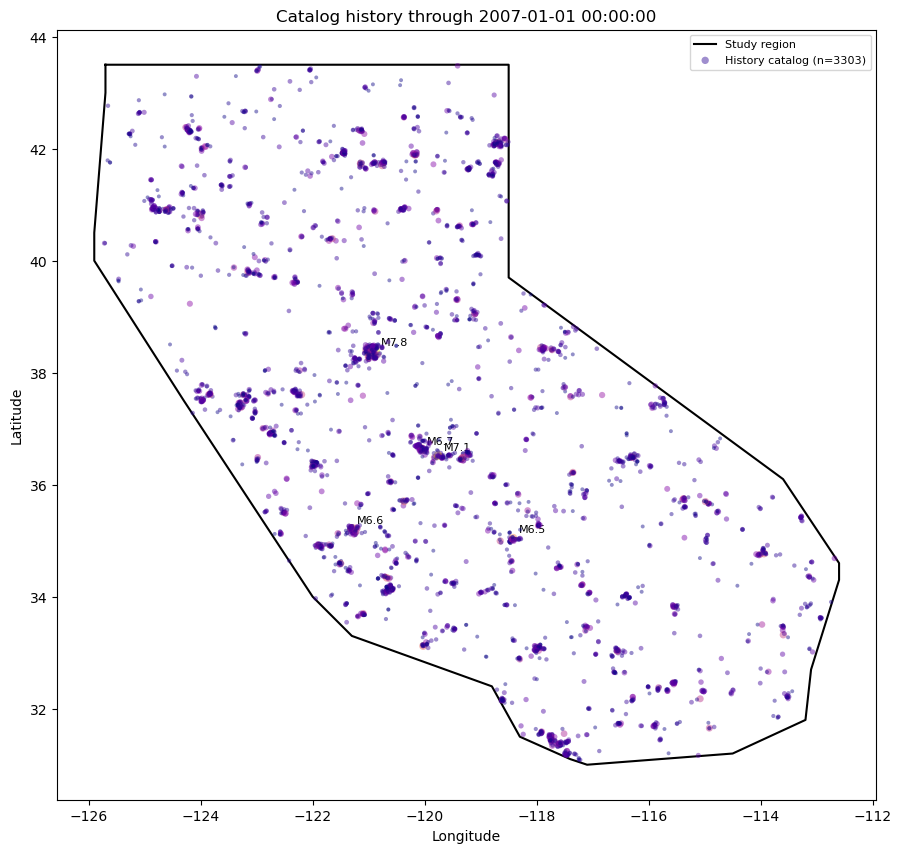

In [7]:
fig, ax = plt.subplots(figsize=(12, 10))
plot_polygon_map(ax, polygon, color="black", linewidth=1.5, label="Study region")

# Plot history catalog (may be large); emphasize the largest events.
sizes = 8 + 40 * (history_df["m"] - history_df["m"].min()) / max(history_df["m"].max() - history_df["m"].min(), 1e-6)
ax.scatter(
    history_df["x"],
    history_df["y"],
    s=sizes,
    c=history_df["m"],
    cmap="plasma",
    alpha=0.45,
    edgecolors="none",
    zorder=5,
    label=f"History catalog (n={len(history_df)})",
)
top = history_df.nlargest(min(5, len(history_df)), "m")
for _, row in top.iterrows():
    ax.annotate(
        f"M{row['m']:.1f}",
        (row["x"], row["y"]),
        textcoords="offset points",
        xytext=(4, 4),
        fontsize=8,
    )

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")
ax.set_title(f"Catalog history through {TIMEWINDOW_END}")
ax.legend(loc="upper right", fontsize=8)
plt.show()


## Method A — Classic ETAS catalog continuation (single run)

In [8]:
# Classic ETAS catalog continuation, run ONCE over the forecast window.
theta = {
    key: THETA_0[key]
    for key in ["log10_mu", "log10_k0", "a", "log10_c", "omega", "log10_tau", "log10_d", "gamma", "rho"]
    if key in THETA_0
}


def _to_naive_utc(ts):
    return pd.to_datetime(ts, utc=True).tz_convert(None)


auxiliary_start = pd.to_datetime(AUXILIARY_START, utc=True).tz_convert(None)

np.random.seed(SEED)
etas_cont = simulation.simulate_catalog_continuation(
    auxiliary_catalog=auxiliary_catalog,
    auxiliary_start=auxiliary_start,
    auxiliary_end=forecast_start_dt,
    polygon=polygon,
    simulation_end=forecast_end_dt,
    parameters=dict(theta),
    mc=float(MC),
    beta_main=BETA_MAIN,
    filter_polygon=True,  # default ETAS: trim after simulation
    magnitude_generator=mc_b_est.simulate_magnitudes,
)

etas_cont["time"] = pd.to_datetime(etas_cont["time"], utc=True).dt.tz_convert(None)
etas_catalog = (
    etas_cont.loc[etas_cont["time"] > forecast_start_dt].sort_values("time").reset_index(drop=True)
)
etas_catalog["t"] = (etas_catalog["time"] - pd.Timestamp("1970-01-01")) / pd.Timedelta("1D")
etas_catalog["dt_days"] = etas_catalog["t"] - forecast_start_t
etas_catalog["x"] = etas_catalog["longitude"]
etas_catalog["y"] = etas_catalog["latitude"]
etas_catalog["m"] = etas_catalog["magnitude"]
if "is_background" in etas_catalog.columns:
    etas_catalog["event_source"] = np.where(
        etas_catalog["is_background"].astype(bool), "background", "triggered"
    )

print(f"ETAS continuation: {len(etas_catalog)} events in the {FORECAST_DAYS:.1f}-day window")
etas_catalog.head()


2026-06-26 10:19:34,412 - INFO -   number of background events needed: 231
2026-06-26 10:19:34,412 - INFO -   generating 470 to throw away those outside the polygon
2026-06-26 10:19:34,419 - DEBUG - number of induced events: 0
2026-06-26 10:19:34,424 - DEBUG - number of background events: 231
2026-06-26 10:19:34,425 - DEBUG - number of auxiliary events: 3303
2026-06-26 10:19:34,425 - DEBUG - generation 0
2026-06-26 10:19:34,427 - DEBUG - number of events with aftershocks: 1794
2026-06-26 10:19:34,449 - DEBUG - number of aftershocks: 265
2026-06-26 10:19:34,449 - DEBUG - their number of aftershocks should be:244
2026-06-26 10:19:34,450 - DEBUG - generation 1
2026-06-26 10:19:34,452 - DEBUG - number of events with aftershocks: 130
2026-06-26 10:19:34,461 - DEBUG - number of aftershocks: 234
2026-06-26 10:19:34,462 - DEBUG - their number of aftershocks should be:178
2026-06-26 10:19:34,463 - DEBUG - generation 2
2026-06-26 10:19:34,465 - DEBUG - number of events with aftershocks: 111
2026

,G,angle,degree_lat,degree_lon,evt_id,expected_n_aftershocks,gen_0_parent,generation,is_background,l_hat,...,source_to_end_time_distance,time,time_delta,xi_plus_1,t,dt_days,x,y,m,event_source
0,NaN,0.480341,111.318845,90.280310,NaN,1.222251,3295,1,False,NaN,...,NaN,2007-01-01 19:27:00.111997607,11.504917,1.0,13514.810418,0.842001,-115.067507,35.836085,4.506801,triggered
1,NaN,0.821762,111.318845,90.245266,NaN,0.716669,3295,2,False,NaN,...,NaN,2007-01-03 07:36:27.843009724,1.506571,1.0,13516.316989,2.348572,-115.052466,35.847422,4.012160,triggered
2,NaN,5.203896,111.318845,90.232368,NaN,0.888580,3295,3,False,NaN,...,NaN,2007-01-03 21:31:15.863140930,0.579722,1.0,13516.896711,2.928294,-115.078384,35.858669,4.211385,triggered
3,NaN,NaN,NaN,NaN,3305.0,0.512853,1,0,True,NaN,...,NaN,2007-01-04 09:31:24.718394000,NaN,1.0,13517.396814,3.428396,-120.936228,34.174271,3.702104,background
4,NaN,3.172926,111.318845,91.139800,NaN,0.480248,3293,1,False,NaN,...,NaN,2007-01-05 05:52:38.999385465,15.060070,1.0,13518.244896,4.276478,-118.294272,35.039750,3.641241,triggered


## Method B — Ogata branching-thinning catalog continuation

Branching temporal-thinning of the space-integrated intensity over the same forecast window.

In [9]:
def thinning_next_event_time(intensity_fn, t0, t_end):
    """Ogata (1981) thinning for the next event time in (t0, t_end].

    Returns the next event time, or None if the next event would fall after t_end.
    Valid because lambda_s_total is non-increasing between events, so intensity_fn(t0)
    upper-bounds the intensity until the next accepted event.
    """
    bound = intensity_fn(t0)
    t = t0
    while True:
        if bound <= 0:
            return None
        t += np.random.exponential(1.0 / bound)
        if t > t_end:
            return None
        cand = intensity_fn(t)
        if np.random.uniform() < cand / bound:
            return t
        bound = cand


def simulate_thinning_continuation(
    history_df,
    poly,
    params,
    t_start,
    t_end,
    beta,
    mc,
    resolution: int = A_H_RESOLUTION,
    filter_polygon: bool = True,
):
    """Branching temporal-thinning catalog continuation over (t_start, t_end].

    Mirrors classic ETAS continuation: the history events seed the intensity, each newly
    generated event becomes a parent (branching), times come from Ogata thinning of the
    space-integrated intensity, locations from the per-parent radial kernel (or uniform
    background), and magnitudes from the Gutenberg-Richter generator.

    With filter_polygon=True (default, matching simulate_catalog_continuation): every
    generated event enters the branching state (even if outside the polygon), but only
    in-polygon events are returned in the forecast catalog.
    """
    events = [to_history_dict(row) for _, row in history_df.iterrows()]
    forecast = []
    intensity = lambda t: lambda_s_total(t, events, poly, params, resolution)

    t = t_start
    while True:
        t_next = thinning_next_event_time(intensity, t, t_end)
        if t_next is None:
            break

        w = parent_weights(t_next, events, poly, params, resolution)
        idx = np.random.choice(len(w), p=w)
        if idx == len(w) - 1:
            lat, lon = sample_background_location(poly)
            source = "background"
        else:
            lat, lon = sample_aftershock_location(events[idx], params)
            source = "triggered"

        m = float(mc_b_est.simulate_magnitudes(1, beta, mc)[0])
        event = {"m": m, "x": float(lon), "y": float(lat), "t": float(t_next)}
        events.append(event)  # always branch (matches ETAS: outside events trigger too)
        forecast.append({**event, "event_source": source})
        t = t_next

    out = pd.DataFrame(forecast, columns=["t", "x", "y", "m", "event_source"])
    if filter_polygon:
        out = filter_catalog_to_polygon(out, poly)
    return out


In [10]:
# Ogata branching-thinning catalog continuation, run ONCE over the same window.
np.random.seed(SEED)
thinning_catalog = simulate_thinning_continuation(
    history_df,
    polygon,
    THETA_0,
    forecast_start_t,
    forecast_end_t,
    BETA_MAIN,
    MC,
)
thinning_catalog["dt_days"] = thinning_catalog["t"] - forecast_start_t
print(f"Thinning continuation: {len(thinning_catalog)} events in the {FORECAST_DAYS:g}-day window")
thinning_catalog.head()


Thinning continuation: 2127 events in the 5114.03-day window


,t,x,y,m,event_source,dt_days
0,13515.833702,-115.381527,35.808598,3.761060,triggered,1.865285
1,13516.874540,-117.105629,33.451777,4.440460,triggered,2.906122
2,13517.558170,-118.482190,34.679199,3.783738,triggered,3.589753
3,13517.755393,-117.114086,33.470902,4.049776,triggered,3.786976
4,13518.013275,-117.092267,33.475529,3.610240,triggered,4.044858


## Comparison: ETAS vs thinning

Each method is a **single** stochastic catalog, so exact overlap is not expected; the cumulative count, spatial spread, and magnitude-frequency should be statistically consistent.

2026-06-26 10:30:46,952 - DEBUG - vmin 0.6817287750643443 vmax 3120.0091265023207
2026-06-26 10:30:46,953 - DEBUG - ticklocs array([1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03, 1.e+04, 1.e+05])
2026-06-26 10:30:46,957 - DEBUG - vmin 0.6817287750643443 vmax 3120.0091265023207
2026-06-26 10:30:46,957 - DEBUG - ticklocs array([2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00, 5.e+00, 6.e+00, 7.e+00, 8.e+00, 9.e+00,
       2.e+01, 3.e+01, 4.e+01, 5.e+01, 6.e+01, 7.e+01, 8.e+01, 9.e+01,
       2.e+02, 3.e+02, 4.e+02, 5.e+02, 6.e+02, 7.e+02, 8.e+02, 9.e+02,
       2.e+03, 3.e+03, 4.e+03, 5.e+03, 6.e+03, 7.e+03, 8.e+03, 9.e+03,
       2.e+04, 3.e+04, 4.e+04, 5.e+04, 6.e+04, 7.e+04, 8.e+04, 9.e+04,
       2.e+05, 3.e+05, 4.e+05, 5.e+05, 6.e+05, 7.e+05, 8.e+05, 9.e+05])
2026-06-26 10:30:46,957 - DEBUG - vmin 0.6817287750643443 vmax 3120.0091265023207
2026-06-26 10:30:46,958 - D

2026-06-26 10:30:47,044 - DEBUG - findfont: score(FontEntry(fname='/usr/share/fonts/truetype/open-sans/OpenSans-ExtraBoldItalic.ttf', name='Open Sans', style='italic', variant='normal', weight=800, stretch='normal', size='scalable')) = 11.43
2026-06-26 10:30:47,045 - DEBUG - findfont: score(FontEntry(fname='/usr/share/fonts/opentype/urw-base35/P052-Italic.otf', name='P052', style='italic', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.05
2026-06-26 10:30:47,045 - DEBUG - findfont: score(FontEntry(fname='/usr/share/fonts/truetype/lyx/esint10.ttf', name='esint10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-06-26 10:30:47,045 - DEBUG - findfont: score(FontEntry(fname='/usr/share/fonts/opentype/stix/STIXVariants-Regular.otf', name='STIXVariants', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-06-26 10:30:47,045 - DEBUG - findfont: score(FontEntry(fname='/usr/share/fo

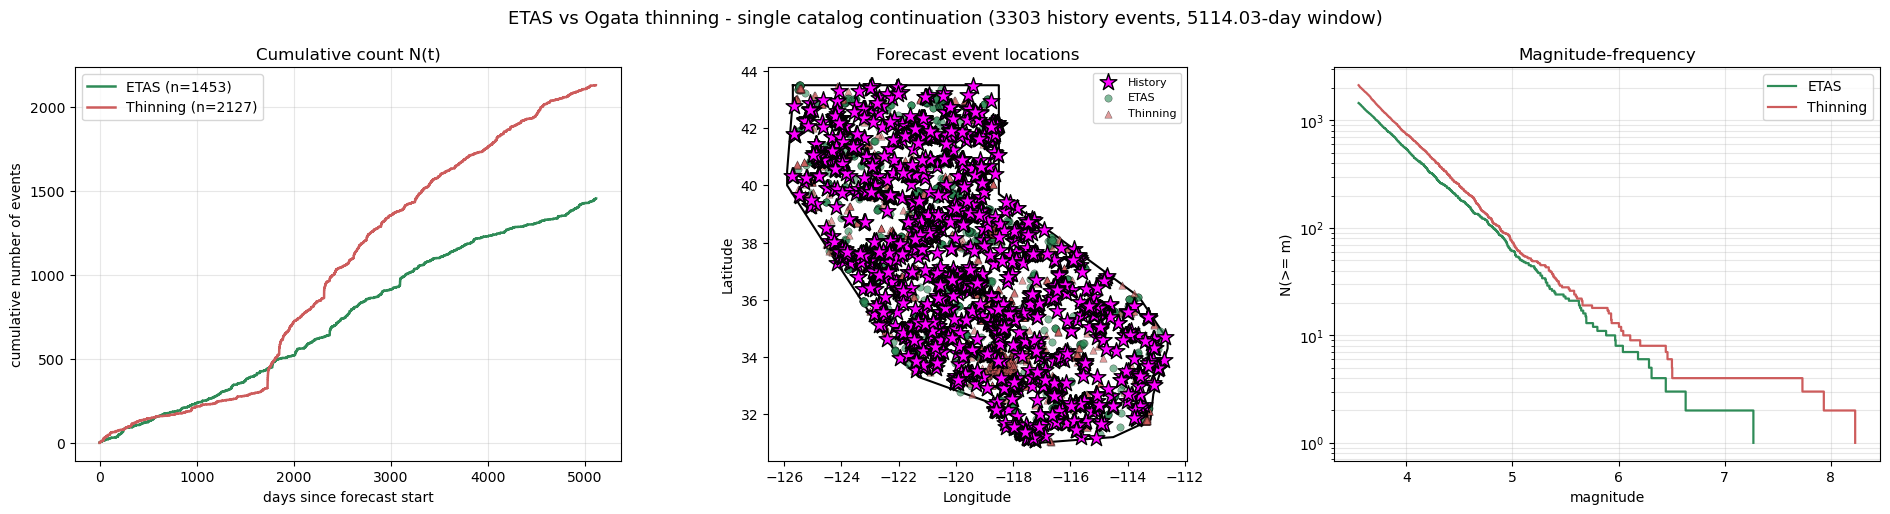

,ETAS,Thinning
metric,,
events in window,1453.000000,2127.000000
background,231.000000,223.000000
triggered,1222.000000,1904.000000
median dt [days],2477.095903,2550.238429
max magnitude,7.270355,8.229553


In [11]:
ETAS_COLOR = "seagreen"
THINNING_COLOR = "indianred"

fig, axes = plt.subplots(1, 3, figsize=(19, 5.2))

# (1) cumulative count N(t) over the window
ax = axes[0]
for cat, color, label in [(etas_catalog, ETAS_COLOR, "ETAS"), (thinning_catalog, THINNING_COLOR, "Thinning")]:
    d = np.sort(cat["dt_days"].to_numpy())
    n = np.arange(1, d.size + 1)
    ax.step(np.concatenate(([0.0], d)), np.concatenate(([0], n)), where="post", color=color, lw=1.8,
            label=f"{label} (n={d.size})")
ax.set_xlabel("days since forecast start")
ax.set_ylabel("cumulative number of events")
ax.set_title("Cumulative count N(t)")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left")

# (2) spatial map
ax = axes[1]
plot_polygon_map(ax, polygon, color="black", linewidth=1.5)
ax.scatter(history_df["x"], history_df["y"], marker="*", s=160, c="magenta",
           edgecolors="black", zorder=6, label="History")
ax.scatter(etas_catalog["x"], etas_catalog["y"], s=28, c=ETAS_COLOR, alpha=0.6,
           edgecolors="black", linewidths=0.3, zorder=4, label="ETAS")
ax.scatter(thinning_catalog["x"], thinning_catalog["y"], s=28, c=THINNING_COLOR, alpha=0.6,
           marker="^", edgecolors="black", linewidths=0.3, zorder=5, label="Thinning")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")
ax.set_title("Forecast event locations")
ax.legend(loc="upper right", fontsize=8)

# (3) magnitude-frequency (cumulative N >= m)
ax = axes[2]
for cat, color, label in [(etas_catalog, ETAS_COLOR, "ETAS"), (thinning_catalog, THINNING_COLOR, "Thinning")]:
    if len(cat):
        m_sorted = np.sort(cat["m"].to_numpy())
        n_ge = np.arange(len(m_sorted), 0, -1)
        ax.step(m_sorted, n_ge, where="post", color=color, lw=1.6, label=label)
ax.set_yscale("log")
ax.set_xlabel("magnitude")
ax.set_ylabel("N(>= m)")
ax.set_title("Magnitude-frequency")
ax.grid(True, which="both", alpha=0.3)
ax.legend()

fig.suptitle(
    f"ETAS vs Ogata thinning - single catalog continuation "
    f"({len(history_df)} history events, {FORECAST_DAYS:g}-day window)",
    fontsize=13,
)
fig.tight_layout()
plt.show()

summary = pd.DataFrame(
    {
        "metric": ["events in window", "background", "triggered",
                   "median dt [days]", "max magnitude"],
        "ETAS": [
            len(etas_catalog),
            int((etas_catalog.get("event_source") == "background").sum()) if "event_source" in etas_catalog else np.nan,
            int((etas_catalog.get("event_source") == "triggered").sum()) if "event_source" in etas_catalog else np.nan,
            float(np.median(etas_catalog["dt_days"])) if len(etas_catalog) else np.nan,
            float(etas_catalog["m"].max()) if len(etas_catalog) else np.nan,
        ],
        "Thinning": [
            len(thinning_catalog),
            int((thinning_catalog["event_source"] == "background").sum()),
            int((thinning_catalog["event_source"] == "triggered").sum()),
            float(np.median(thinning_catalog["dt_days"])) if len(thinning_catalog) else np.nan,
            float(thinning_catalog["m"].max()) if len(thinning_catalog) else np.nan,
        ],
    }
).set_index("metric")
summary


## More comparisons: conditional intensity λ_s(t) and binned magnitude-frequency

- **Left:** the space-integrated conditional intensity `λ_s(t) = μ·area + Σ_i A_h(poly, H_i)·g(t, H_i)`. The black curve is the history-only driving rate; the coloured curves are each method's *realized* self-exciting intensity (history + that catalog's own events), so every event makes the rate jump up. Ticks at the bottom mark event times.
- **Right:** incremental (binned) magnitude-frequency with the Gutenberg–Richter expectation (dashed) scaled to each catalog's event count.

2026-06-26 10:32:33,623 - DEBUG - vmin 0.019020274300879533 vmax 54.033521952052915
2026-06-26 10:32:33,624 - DEBUG - ticklocs array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03])
2026-06-26 10:32:33,627 - DEBUG - vmin 0.019020274300879533 vmax 54.033521952052915
2026-06-26 10:32:33,627 - DEBUG - ticklocs array([2.e-03, 3.e-03, 4.e-03, 5.e-03, 6.e-03, 7.e-03, 8.e-03, 9.e-03,
       2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00, 5.e+00, 6.e+00, 7.e+00, 8.e+00, 9.e+00,
       2.e+01, 3.e+01, 4.e+01, 5.e+01, 6.e+01, 7.e+01, 8.e+01, 9.e+01,
       2.e+02, 3.e+02, 4.e+02, 5.e+02, 6.e+02, 7.e+02, 8.e+02, 9.e+02,
       2.e+03, 3.e+03, 4.e+03, 5.e+03, 6.e+03, 7.e+03, 8.e+03, 9.e+03])
2026-06-26 10:32:33,628 - DEBUG - vmin 0.019020274300879533 vmax 54.033521952052915
2026-06-26 10:32:33,628 - DEBUG - ticklocs array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.

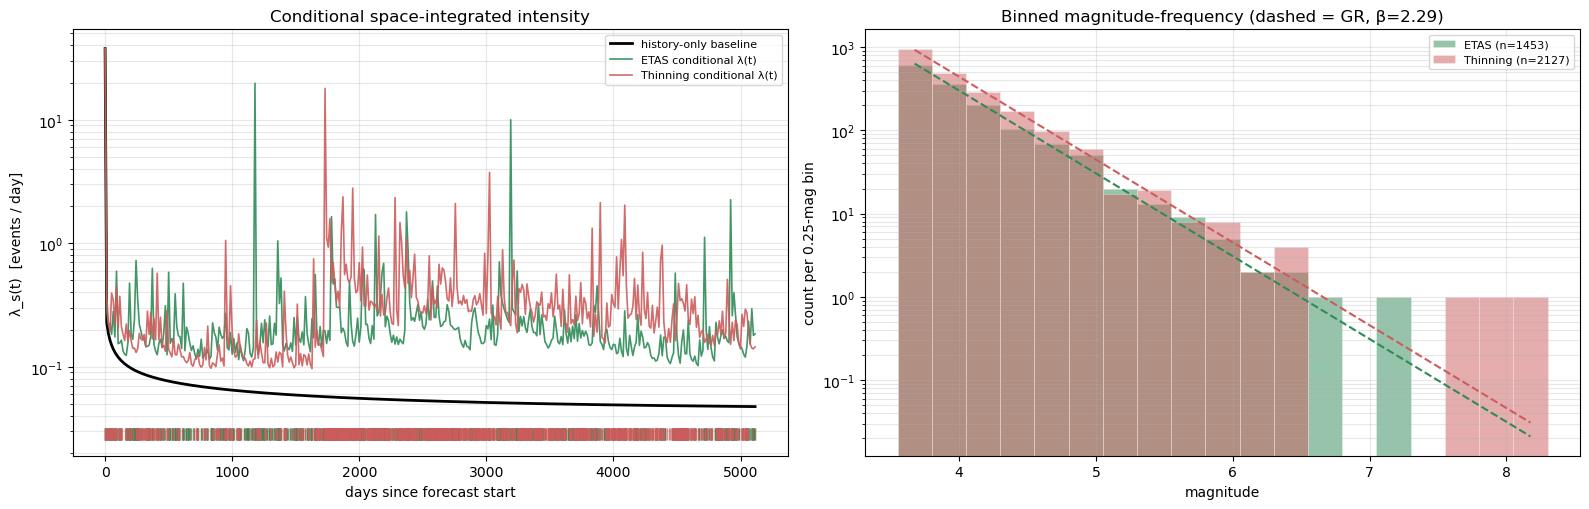

In [12]:
fig, (ax_t, ax_m) = plt.subplots(1, 2, figsize=(16, 5.2))

# ---------- (left) conditional space-integrated intensity lambda_s(t) ----------
t_grid = np.linspace(forecast_start_t, forecast_end_t, 400)
dt_grid = t_grid - forecast_start_t

hist_events = [to_history_dict(row) for _, row in history_df.iterrows()]
lam_hist = np.array([lambda_s_total(t, hist_events, polygon, THETA_0) for t in t_grid])
ax_t.plot(dt_grid, lam_hist, color="black", lw=2.0, label="history-only baseline")


def _events_from_catalog(cat):
    evs = list(hist_events)
    for _, r in cat.iterrows():
        evs.append({"m": float(r["m"]), "x": float(r["x"]), "y": float(r["y"]), "t": float(r["t"])})
    return evs


y_tick = max(lam_hist.min(), 1e-3)
for cat, color, label in [(etas_catalog, ETAS_COLOR, "ETAS"), (thinning_catalog, THINNING_COLOR, "Thinning")]:
    evs = _events_from_catalog(cat)
    lam = np.array([lambda_s_total(t, evs, polygon, THETA_0) for t in t_grid])
    ax_t.plot(dt_grid, lam, color=color, lw=1.2, alpha=0.9, label=f"{label} conditional λ(t)")
    if len(cat):
        ax_t.plot(cat["dt_days"], np.full(len(cat), y_tick * 0.6), "|", color=color, markersize=9, alpha=0.7)

ax_t.set_yscale("log")
ax_t.set_ylim(bottom=y_tick * 0.4)
ax_t.set_xlabel("days since forecast start")
ax_t.set_ylabel("λ_s(t)  [events / day]")
ax_t.set_title("Conditional space-integrated intensity")
ax_t.grid(True, which="both", alpha=0.3)
ax_t.legend(fontsize=8, loc="upper right")

# ---------- (right) incremental (binned) magnitude-frequency ----------
all_m = np.concatenate([etas_catalog["m"].to_numpy(), thinning_catalog["m"].to_numpy()])
m_hi = float(all_m.max()) if all_m.size else MC + 1.0
m_bins = np.arange(MC, m_hi + 0.25, 0.25)
centers = 0.5 * (m_bins[:-1] + m_bins[1:])

for cat, color, label in [(etas_catalog, ETAS_COLOR, "ETAS"), (thinning_catalog, THINNING_COLOR, "Thinning")]:
    if len(cat):
        ax_m.hist(cat["m"], bins=m_bins, color=color, alpha=0.5, edgecolor="white",
                  linewidth=0.4, label=f"{label} (n={len(cat)})")
        # Gutenberg-Richter expected count per bin, scaled to this catalog's size
        gr_counts = len(cat) * (
            np.exp(-BETA_MAIN * (m_bins[:-1] - MC)) - np.exp(-BETA_MAIN * (m_bins[1:] - MC))
        )
        ax_m.plot(centers, gr_counts, color=color, ls="--", lw=1.5)

ax_m.set_yscale("log")
ax_m.set_xlabel("magnitude")
ax_m.set_ylabel("count per 0.25-mag bin")
ax_m.set_title(f"Binned magnitude-frequency (dashed = GR, β={BETA_MAIN:.2f})")
ax_m.grid(True, which="both", alpha=0.3)
ax_m.legend(fontsize=8)

fig.tight_layout()
plt.show()


## Magnitude vs time + cumulative count (ETAS vs thinning)

Top: stem/scatter of event magnitude against time (days since forecast start), ETAS and thinning overlaid in their colour code with the history events marked. Bottom (shared x-axis): cumulative number of forecast events N(t).

/tmp/ipykernel_644260/2736206937.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


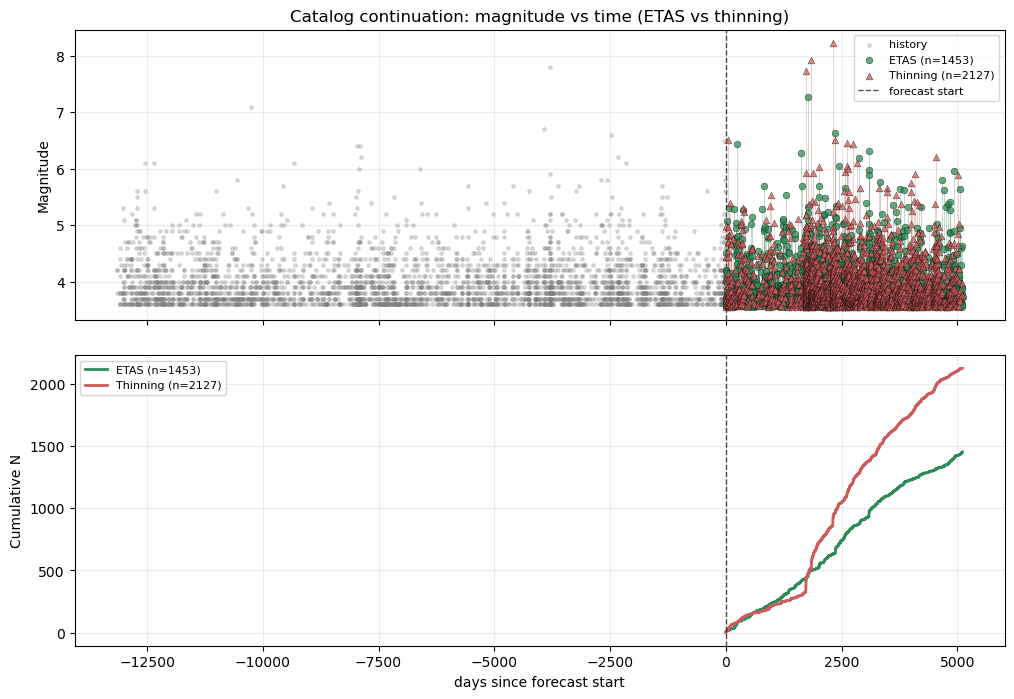

In [13]:
fig, (ax_mag, ax_cum) = plt.subplots(
    2, 1, figsize=(12, 8), sharex=True, gridspec_kw={"hspace": 0.12}
)

# --- top: magnitude vs time ---
if len(history_df):
    hist_dt = history_df["t"].to_numpy() - forecast_start_t
    ax_mag.scatter(hist_dt, history_df["m"], s=6, c="gray", alpha=0.25, zorder=3, label="history")

for cat, color, label, marker in [
    (etas_catalog, ETAS_COLOR, "ETAS", "o"),
    (thinning_catalog, THINNING_COLOR, "Thinning", "^"),
]:
    if len(cat):
        ax_mag.vlines(cat["dt_days"], MC, cat["m"], color=color, lw=0.6, alpha=0.35)
        ax_mag.scatter(cat["dt_days"], cat["m"], s=24, c=color, marker=marker, alpha=0.75,
                       edgecolors="black", linewidths=0.3, zorder=4, label=f"{label} (n={len(cat)})")

ax_mag.axvline(0.0, color="black", ls="--", lw=1.0, alpha=0.7, label="forecast start")
ax_mag.set_ylabel("Magnitude")
ax_mag.set_title("Catalog continuation: magnitude vs time (ETAS vs thinning)")
ax_mag.grid(True, alpha=0.25)
ax_mag.legend(loc="upper right", fontsize=8)

# --- bottom: cumulative number of events ---
for cat, color, label in [
    (etas_catalog, ETAS_COLOR, "ETAS"),
    (thinning_catalog, THINNING_COLOR, "Thinning"),
]:
    if len(cat):
        d = np.sort(cat["dt_days"].to_numpy())
        ax_cum.plot(np.concatenate(([0.0], d)), np.arange(0, d.size + 1),
                    drawstyle="steps-post", color=color, lw=2.0, label=f"{label} (n={d.size})")

ax_cum.axvline(0.0, color="black", ls="--", lw=1.0, alpha=0.7)
ax_cum.set_xlabel("days since forecast start")
ax_cum.set_ylabel("Cumulative N")
ax_cum.grid(True, alpha=0.25)
ax_cum.legend(loc="upper left", fontsize=8)

fig.tight_layout()
plt.show()


## Spatial map: history + forecast catalogs

California polygon with history events (magenta stars) and the ETAS / thinning forecast locations overlaid in their colour code. Marker size scales with magnitude.

2026-06-26 10:32:34,583 - DEBUG - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=9.0.
2026-06-26 10:32:34,584 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/cmr10.ttf', name='cmr10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-06-26 10:32:34,584 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizOneSymReg.ttf', name='STIXSizeOneSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-06-26 10:32:34,584 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSansMono.ttf', name='DejaVu San

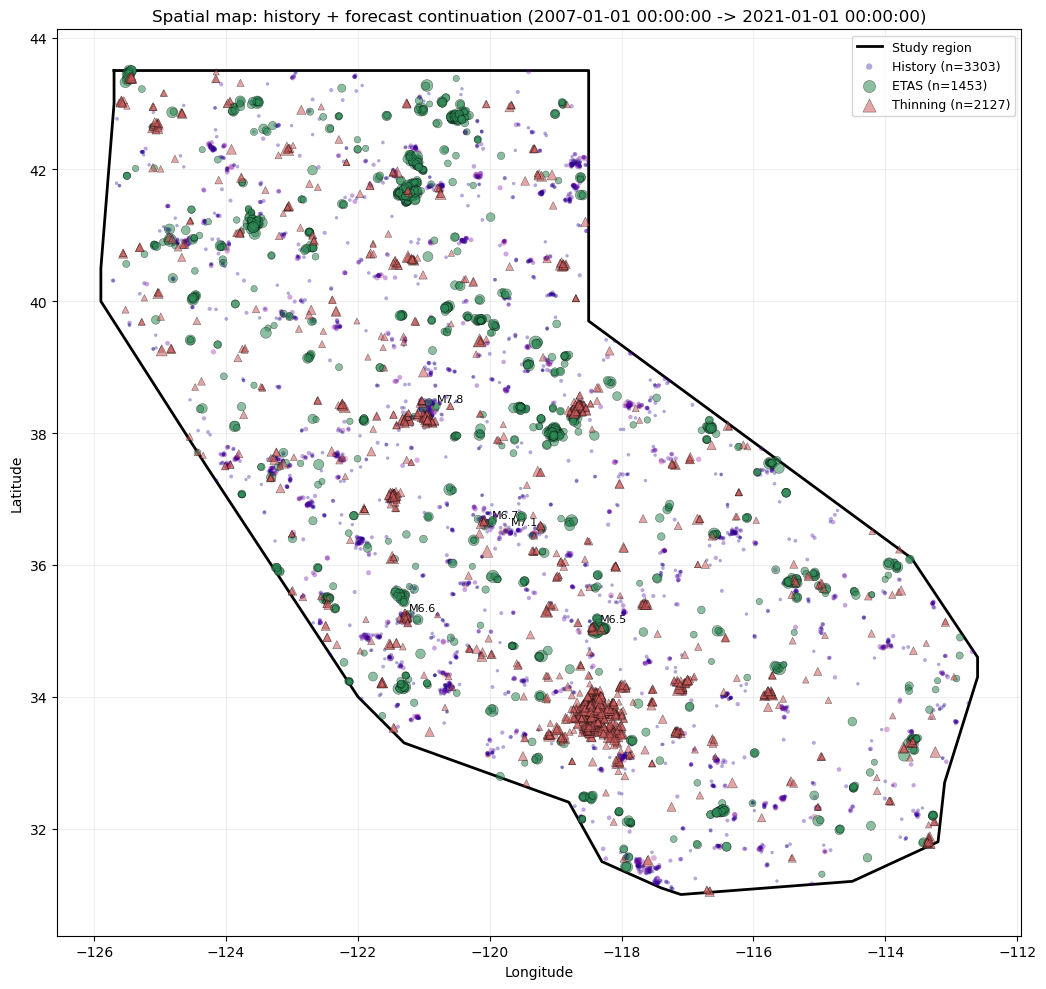

In [14]:
fig_map, ax = plt.subplots(figsize=(12, 10))

plot_polygon_map(ax, polygon, color="black", linewidth=2, label="Study region")

# history catalog (may be large)
if len(history_df):
    m_span = max(history_df["m"].max() - history_df["m"].min(), 1e-6)
    ax.scatter(
        history_df["x"],
        history_df["y"],
        s=6 + 30 * (history_df["m"] - history_df["m"].min()) / m_span,
        c=history_df["m"],
        cmap="plasma",
        alpha=0.35,
        edgecolors="none",
        zorder=4,
        label=f"History (n={len(history_df)})",
    )
    for _, row in history_df.nlargest(min(5, len(history_df)), "m").iterrows():
        ax.annotate(
            f"M{row['m']:.1f}",
            (row["x"], row["y"]),
            textcoords="offset points",
            xytext=(4, 4),
            fontsize=8,
        )

for cat, color, label, marker in [
    (etas_catalog, ETAS_COLOR, "ETAS", "o"),
    (thinning_catalog, THINNING_COLOR, "Thinning", "^"),
]:
    if len(cat):
        sizes = 20 + 30 * (cat["m"] - MC)
        ax.scatter(
            cat["x"], cat["y"], s=sizes, c=color, marker=marker, alpha=0.55,
            edgecolors="black", linewidths=0.35, zorder=6, label=f"{label} (n={len(cat)})",
        )

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")
ax.set_title(
    f"Spatial map: history + forecast continuation ({TIMEWINDOW_END} -> {TESTWINDOW_END})"
)
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.2)
fig_map.tight_layout()
plt.show()
